# Image Acquisition

Acquire a full-frame image, a cropped rectangle scan, and images from multiple detectors.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import tango
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl

### Ping servers


In [3]:
# DB_HOST = "10.46.217.241"
DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/microscope/default ON
asyncroscopy/data/default ON


### Start Tiled data server


In [4]:
from pathlib import Path
# TILED_HOST = "10.46.217.241"
# TILED_PORT = 9091

TILED_HOST = "localhost"
TILED_PORT = 9091

save_path = Path.cwd().parent / "outputs" / "tiled_acquisitions"
save_path.mkdir(parents=True, exist_ok=True)
print(f"Saving acquired data to: {save_path}")

Saving acquired data to: c:\Users\utkarsh.pratiush\Documents\repos\asyncroscopy\outputs\tiled_acquisitions


In [5]:
data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = str(save_path)

if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))

client = from_uri(config.get("uri", f"http://{TILED_HOST}:{TILED_PORT}"))
print("Tiled keys:", list(client))


Tiled server is already running.
{
  "host": "localhost",
  "port": 9091,
  "uri": "http://localhost:9091",
  "save_path": "c:\\Users\\utkarsh.pratiush\\Documents\\repos\\asyncroscopy\\outputs\\tiled_acquisitions",
  "tiled_server": "yes",
  "tiled_server_status": "running; serving path; files register manually",
  "tiled_server_serving": "c:\\Users\\utkarsh.pratiush\\Documents\\repos\\asyncroscopy\\outputs\\tiled_acquisitions"
}
Tiled keys: ['stem_image_HAADF_20260602T074251210320.h5', 'stem_image_HAADF_20260603T151413278920.h5', 'stem_image_HAADF_BF-S_DF-S_20260603T151625188975.h5', "stem_image_['HAADF']_20260604T123909936109.tiff", 'stem_image_HAADF_20260604T124103341637.h5', "stem_image_['HAADF']_20260604T124340133951.tiff", "stem_image_['HAADF']_20260604T124348937617.tiff", 'stem_image_HAADF_20260604T132409986976.h5', 'stem_image_HAADF_BF-S_DF-S_20260604T132417689146.h5', 'stem_image_20260604T132426343082_HAADF.tiff', 'stem_image_20260604T132426343082_BF-S.tiff', 'stem_image_20260

### Configure scan


In [6]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".h5"

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


### Acquire a HAADF image


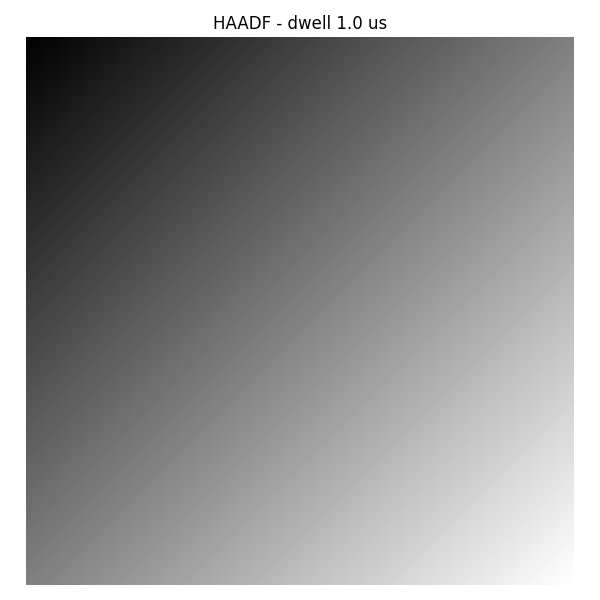

In [7]:
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

In [34]:
print("Metadata:")
pprint(metadata)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)


Metadata:
{'AccelerationVoltage': '300000',
 'AcquisitionDatetime': '2026-06-04T13:24:09.9341586-07:00',
 'AcquisitionStartDatetime': '2026-06-04T20:24:09.9411585Z',
 'AcquisitionUnit': 'Pixel',
 'Alpha': '0',
 'ApplicationSoftware': 'AutoScript TEM',
 'ApplicationSoftwareVersion': '1.17.0.342',
 'BeamCurrent': '4e-09',
 'BeamDiameter': '0',
 'BeamType': 'Electron',
 'Beta': '0',
 'CameraLength': '0',
 'CompositionType': 'Single',
 'ComputerName': 'UPRATIUSH-T14G6',
 'Defocus': '0',
 'Detector': 'HAADF',
 'DetectorName': 'HAADF',
 'DetectorType': 'ScanningDetector',
 'DwellTime': '1e-06',
 'EFTEMOn': 'false',
 'ExtractorVoltage': '4000',
 'Focus': '0',
 'Gamma': '1',
 'Guid': '9203c3c1-5040-4b3a-92ec-30ff771a1650',
 'GunLensSetting': '0',
 'Height': '512',
 'Height_54': '512',
 'HolderType': 'DoubleTilt',
 'IlluminationIntensityNormalized': '50',
 'InstrumentID': '12345',
 'InstrumentModel': 'Fake_Talos',
 'IntensityOffset': '0',
 'IntensityScale': '1',
 'Manufacturer': 'FEI Company',


### Acquire multiple detectors


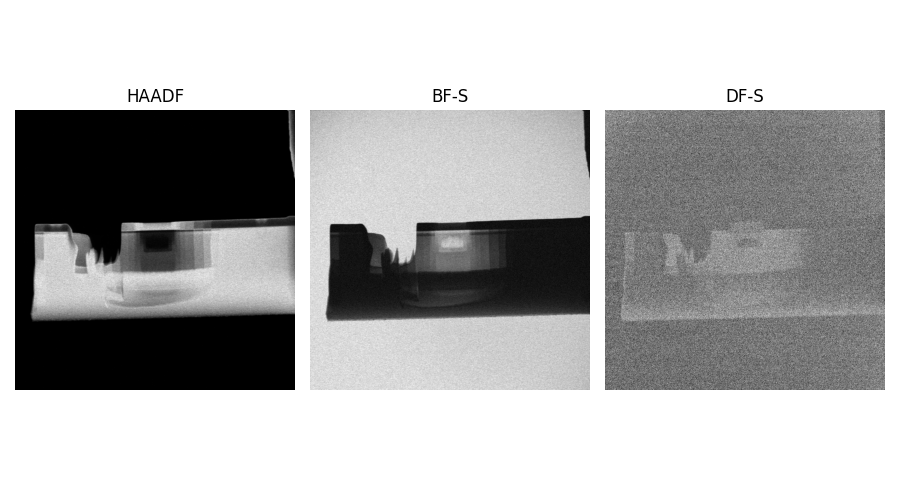

In [6]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(["HAADF", "BF-S", "DF-S"])
dset = client[key]["image"]

images = []
names = []
for detector_name in dset:
    image = dset[detector_name].read()
    images.append(image)
    names.append(detector_name)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()


## if using tiff as output fomrat(AutoScript Native) i.e scan.output_format = ".tiff"

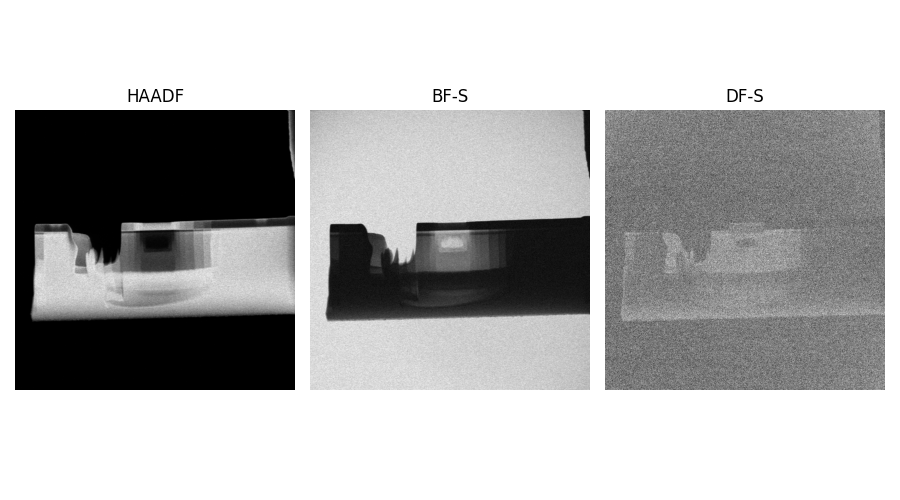

In [7]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".tiff"

detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(detector_list)   # returns the shared stem, e.g. "stem_image_20260604T123909936109"

images = []
names = []
for det in detector_list:
    node = client[f"{key}_{det.upper()}.tiff"]   # one TIFF per detector
    images.append(node.read())                   # read the image array directly
    names.append(det)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()

### Acquire a cropped rectangle scan


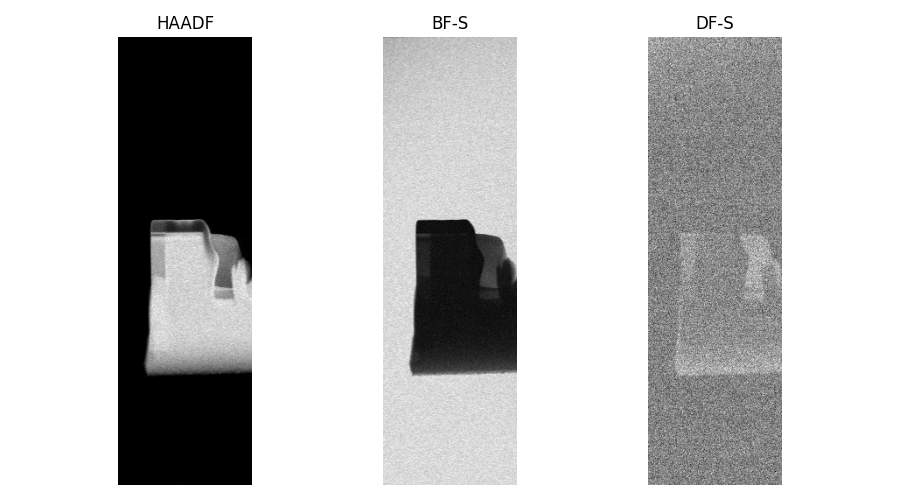

In [9]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.output_format = ".tiff"
scan.scan_region = [0, 0, .3, 1]


detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(detector_list)   # returns the shared stem, e.g. "stem_image_20260604T123909936109"

images = []
names = []
for det in detector_list:
    node = client[f"{key}_{det.upper()}.tiff"]   # one TIFF per detector
    images.append(node.read())                   # read the image array directly
    names.append(det)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()

## Lets do some acquisiton on the Camera now to get some diffraction patterns.
**Make sure to check the screen current(less than 100 pico Amps should be good)**